# Agent Tool Use & Structured Outputs
**Module 3: GenAI & Agents | ~90 min**

- Function calling
- Tool descriptions
- Execution cycle
- Native vs Custom tools
- JSON schema contracts
- Pydantic validation
- Output parsing


## Setup


In [ ]:
!pip install openai pydantic --quiet


In [ ]:
from openai import OpenAI
from getpass import getpass
from pydantic import BaseModel, ValidationError

api_key = getpass("Enter your OpenRouter API key: ")
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=api_key)
MODEL = "deepseek/deepseek-v4-flash-0731:free"


## 1. Function Calling

- Last 2 sessions: we told the model to reply in a text format (`Action: lookup[...]`) and parsed it ourselves
- **Function calling** = the API itself understands "tools" — the model returns structured tool calls, not text to parse
- More reliable, less string-parsing


## 2. Tool Descriptions

- A tool is described once: **name**, **description**, **parameters** (JSON schema)
- The model reads this to decide *when* and *how* to call it — you never call it yourself in the description

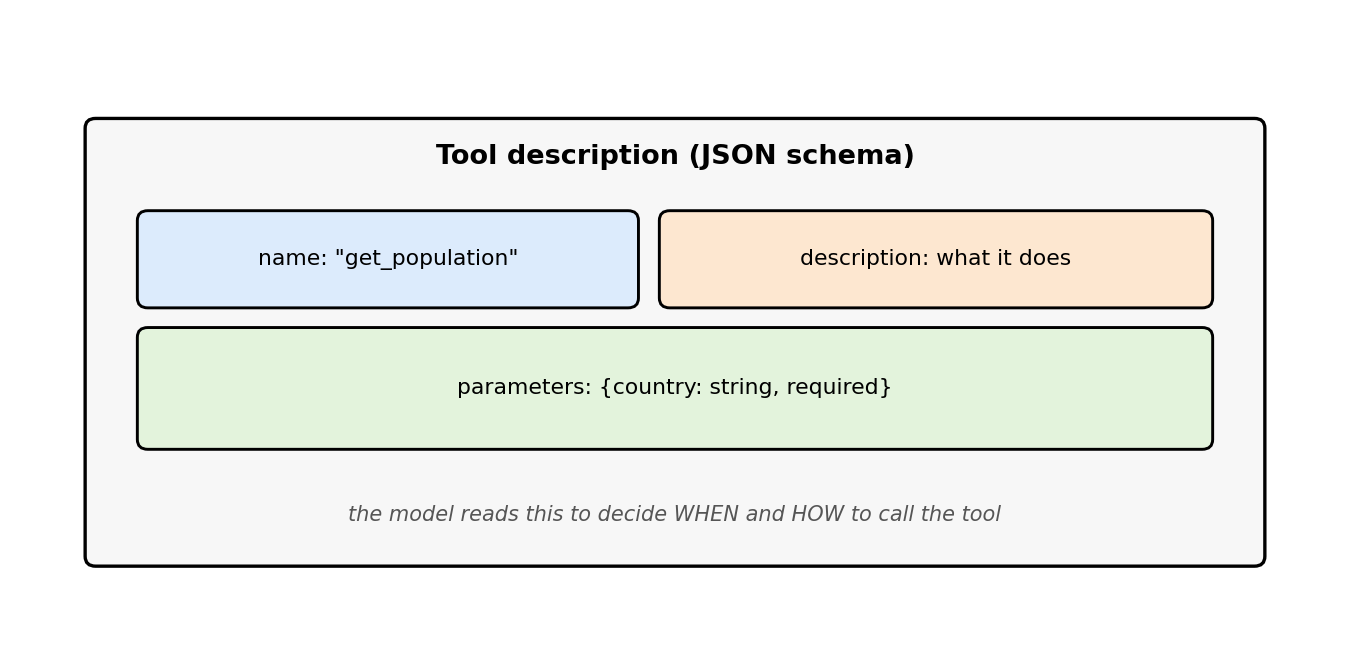


In [ ]:
def get_population(country):
    population_db = {"japan": 13960000, "egypt": 9500000, "france": 2148000}
    return population_db.get(country.lower(), "unknown")

tools = [{
    "type": "function",
    "function": {
        "name": "get_population",
        "description": "Get the population of a country's capital city.",
        "parameters": {
            "type": "object",
            "properties": {
                "country": {"type": "string", "description": "The country name, e.g. Japan"}
            },
            "required": ["country"],
        },
    },
}]


## 3. The Execution Cycle

1. User asks
2. Model picks a tool + arguments (does **not** run it)
3. Your code runs the real function
4. Result goes back to the model
5. Model answers (or calls another tool)

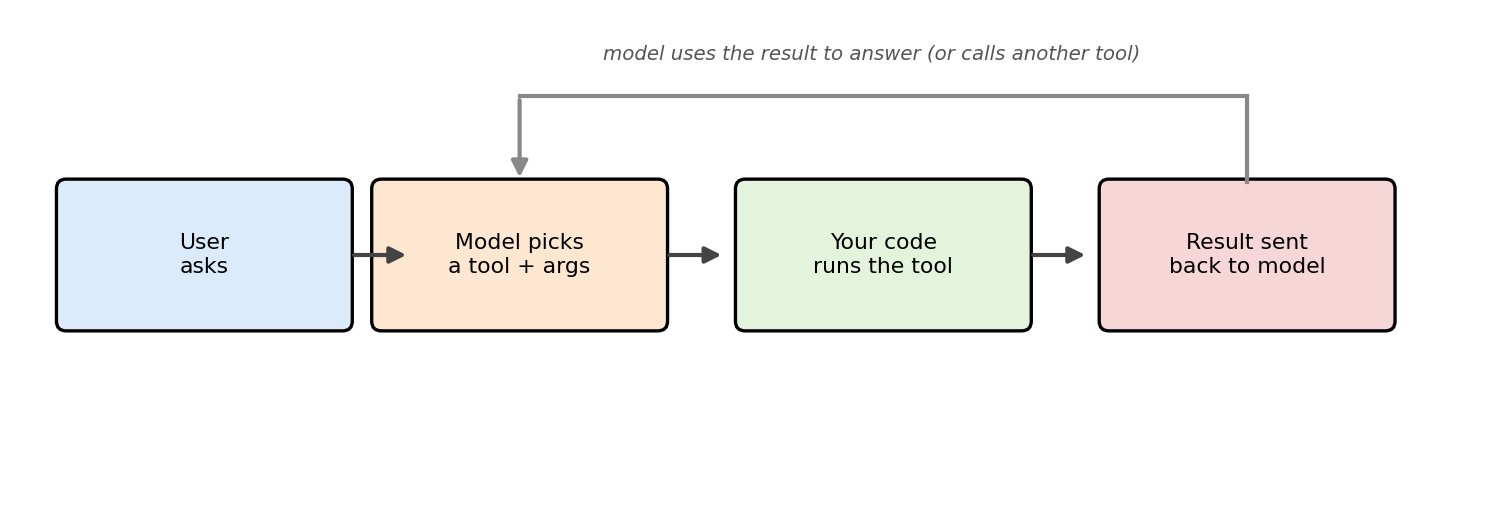


In [ ]:
class GetPopulationArgs(BaseModel):
    country: str


In [1]:
messages = [{"role": "user", "content": "What is the population of the capital of Japan?"}]

response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
reply = response.choices[0].message

if reply.tool_calls:
    messages.append({
        "role": "assistant",
        "content": reply.content,
        "tool_calls": [
            {"id": tc.id, "type": "function",
             "function": {"name": tc.function.name, "arguments": tc.function.arguments}}
            for tc in reply.tool_calls
        ],
    })
    for tc in reply.tool_calls:
        args = GetPopulationArgs.model_validate_json(tc.function.arguments)   # validate before calling!
        print(f"Model wants to call: get_population(country={args.country!r})")
        result = get_population(args.country)
        print(f"Tool result: {result}")
        messages.append({"role": "tool", "tool_call_id": tc.id, "content": str(result)})

    response2 = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    final_reply = response2.choices[0].message.content
    print("Final reply:", final_reply)


Model wants to call: get_population(country='Japan')
Tool result: 13960000
Final reply: The population of Japan's capital, Tokyo, is 13,960,000.


## 4. Native vs Custom Tools

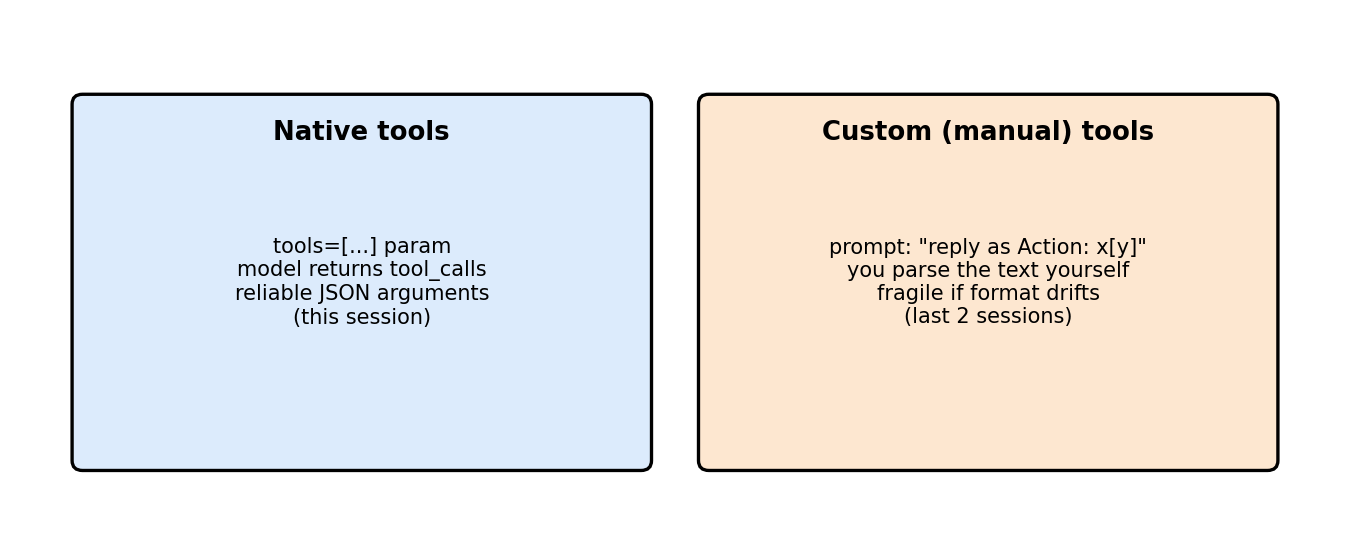


## 5. JSON Schema Contracts

- The `parameters` block above **is** a JSON schema — a contract the model must fill
- `type`, `properties`, `required` are the core pieces
- A stricter schema (enums, number bounds, nested objects) = fewer malformed calls


In [2]:
stricter_tool = {
    "type": "function",
    "function": {
        "name": "convert_temperature",
        "description": "Convert a temperature between units.",
        "parameters": {
            "type": "object",
            "properties": {
                "value": {"type": "number"},
                "from_unit": {"type": "string", "enum": ["celsius", "fahrenheit"]},
                "to_unit": {"type": "string", "enum": ["celsius", "fahrenheit"]},
            },
            "required": ["value", "from_unit", "to_unit"],
        },
    },
}
stricter_tool["function"]["parameters"]


{'type': 'object',\n 'properties': {'value': {'type': 'number'},\n  'from_unit': {'type': 'string', 'enum': ['celsius', 'fahrenheit']},\n  'to_unit': {'type': 'string', 'enum': ['celsius', 'fahrenheit']}},\n'required': ['value', 'from_unit', 'to_unit']}

## 6. Pydantic Validation

- Even with a schema, models sometimes send bad arguments (missing field, wrong type)
- **Pydantic** turns the raw JSON string into a real, checked Python object — or raises a clear error


In [3]:
# valid
GetPopulationArgs.model_validate_json('{"country": "Japan"}')


GetPopulationArgs(country='Japan')

In [4]:
# invalid -- missing required field
try:
    GetPopulationArgs.model_validate_json('{"place": "Japan"}')
except ValidationError as e:
    print(e)


1 validation error for GetPopulationArgs
country
  Field required [type=missing, input_value={'place': 'Japan'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing


**Rule of thumb:** validate tool arguments *before* calling the real function — never trust raw model output directly.


## 7. Output Parsing

- Same idea applies to the model's **final** answer: ask for structured JSON, then validate it
- Turns "hopefully well-formatted text" into a guaranteed, typed object


In [ ]:
class Answer(BaseModel):
    country: str
    capital: str
    population: int


In [5]:
good_output = '{"country": "Japan", "capital": "Tokyo", "population": 13960000}'
Answer.model_validate_json(good_output)


Answer(country='Japan', capital='Tokyo', population=13960000)

In [6]:
# model returned population as text instead of a number
bad_output = '{"country": "Japan", "capital": "Tokyo", "population": "a lot"}'
try:
    Answer.model_validate_json(bad_output)
except ValidationError as e:
    print(e)


1 validation error for Answer
population
  Input should be a valid integer, unable to parse string as an integer [type=int_parsing, input_value='a lot', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/int_parsing


## Summary

| Concept | One-liner |
|---|---|
| Function calling | Model returns structured tool calls, not text to parse |
| Tool description | name + description + JSON schema `parameters` |
| Execution cycle | ask → model picks tool → you run it → result back → model answers |
| Native vs Custom | native = `tools=[...]` param; custom = manual text parsing (last 2 sessions) |
| JSON schema contract | `type` / `properties` / `required`, optionally `enum` |
| Pydantic validation | catches bad arguments before you call the real function |
| Output parsing | validate the model's final structured answer the same way |

**Try:**
1. Add a `to_fahrenheit: bool` field to `GetPopulationArgs` and see validation reject a call missing it.
2. Add a second tool (e.g. `get_capital`) and let the model chain both calls.
3. Make `Answer.population` a `PositiveInt` and pass `-5` to see the new error.
